In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy
from astropy.wcs import WCS
from astropy.io import fits
import warnings
import os
from astropy.utils.exceptions import AstropyWarning
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames, get_earth

In [2]:
#All the 12 Fermi Flares
flares = [
    "110906925", "120307161", "120307294", "120307426",
    "120706970", "130514104", "131011272", "140225048",
    "140225181", "140901460", "170910794", "170910926"
]

#TS scores here as the loop runs
ts_scores = []

#Header for table
print(f"{'Flare ID':<12} | {'Max TS':<8} | {'RA (deg)':<10} | {'Dec (deg)':<10}")
print("-" * 47)

for flare in flares:
    # Build the file path for each flare
    filepath = f"flare_{flare}/{flare}_tsmap.fits"
    
    # Open the TS Map file
    hdul = fits.open(filepath)
    ts_data = hdul[0].data
    header = hdul[0].header
    hdul.close()

    # Get the coordinate system math from the header
    wcs = WCS(header)

    # Find the exact pixel (x, y) with the highest TS score
    max_y, max_x = np.unravel_index(np.argmax(ts_data, axis=None), ts_data.shape)
    max_ts_value = ts_data[max_y, max_x]

    # Append values to the list
    ts_scores.append(max_ts_value)

    # Convert that pixel into RA & Dec
    ra, dec = wcs.pixel_to_world_values(max_x, max_y)

    print(f"{flare:<12} | {max_ts_value:<8.2f} | {ra:<10.3f} | {dec:<10.3f}")

#There is a long warning output, so we will filter them out..twice
warnings.simplefilter('ignore', AstropyWarning)
warnings.simplefilter('ignore', AstropyWarning)

Flare ID     | Max TS   | RA (deg)   | Dec (deg) 
-----------------------------------------------
110906925    | 1614.05  | 165.130    | 6.619     
120307161    | 35512.86 | 347.911    | -4.959    
120307294    | 21972.81 | 348.135    | -5.008    
120307426    | 5121.50  | 348.057    | -4.956    
120706970    | 17.14    | 105.777    | 22.434    
130514104    | 1939.17  | 51.162     | 18.844    
131011272    | 6754.31  | 196.789    | -7.084    
140225048    | 28945.12 | 338.168    | -9.207    
140225181    | 4598.80  | 338.396    | -9.258    
140901460    | 18303.86 | 160.606    | 8.743     
170910794    | 25933.55 | 168.722    | 4.790     
170910926    | 4379.94  | 168.841    | 4.740     


Set MJD-END to 55810.949421 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 55993.188310 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 55993.320949 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 55993.454282 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 56114.937958 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 56426.144891 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 56576.316986 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 56713.060470 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 56713.193109 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 56901.470949 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 58006.818866 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 58006.950810 from DATE-END'. [astropy.wcs.wcs]


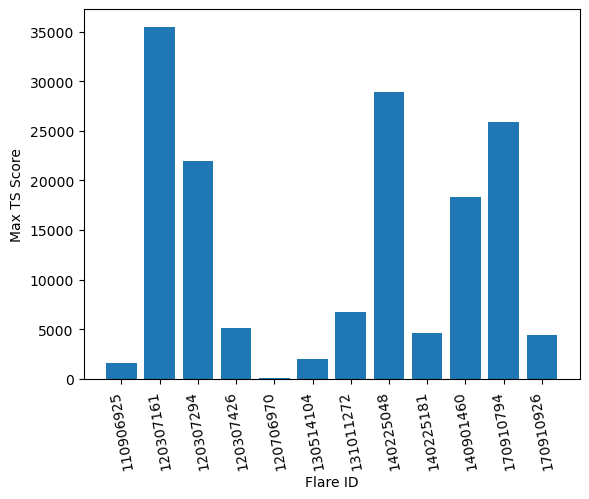

In [ ]:
plt.bar(flares, ts_scores)
plt.xlabel('Flare ID')
plt.ylabel('Max TS Score')
plt.xticks(rotation=100)
# plt.savefig('ts_scores.png', dpi=150)
plt.show()

In [4]:
flare_times = {
    "110906925": "2011-09-06T22:11:00",
    "120307161": "2012-03-07T03:51:00",
    "120307294": "2012-03-07T07:02:00",
    "120307426": "2012-03-07T10:14:00",
    "120706970": "2012-07-06T23:20:00",
    "130514104": "2013-05-14T02:43:00",
    "131011272": "2013-10-11T06:56:00",
    "140225048": "2014-02-25T01:09:00",
    "140225181": "2014-02-25T04:20:00",
    "140901460": "2014-09-01T11:02:00",
    "170910794": "2017-09-10T19:03:00",
    "170910926": "2017-09-10T22:13:00"
}

In [5]:
#Header for table
print(f"{'Flare ID':<12} | {'RA (deg)':<10} | {'Dec (deg)':<10} | {'Helio X (arcsec)':<18} | {'Helio Y (arcsec)':<18}")
print("-" * 75)

helio_x = []
helio_y = []


#loop

for flare in flares:
    # Build the file path for each flare
    filepath = f"flare_{flare}/{flare}_tsmap.fits"
    
    if not os.path.exists(filepath):
        print(f"{flare:<12} | File not found.")
        continue

    #  Open the TS Map file and extract RA & Dec
    hdul = fits.open(filepath)
    ts_data = hdul[0].data
    header = hdul[0].header
    hdul.close()

    wcs = WCS(header)
    max_y, max_x = np.unravel_index(np.argmax(ts_data, axis=None), ts_data.shape)
    ra, dec = wcs.pixel_to_world_values(max_x, max_y)

    # Get the specific start time for this flare 
    flare_time = flare_times[flare]
    
    #  Figure out where Earth was at that exact moment
    earth_observer = get_earth(flare_time)
    distance_to_sun = earth_observer.radius

    #  Create the astropy coordinate object
    flare_celestial = SkyCoord(ra*u.deg, dec*u.deg, distance=distance_to_sun, frame='icrs', obstime=flare_time)

    #  Set up the Helioprojective coordinate frame
    hpc_frame = frames.Helioprojective(observer=earth_observer, obstime=flare_time)

    # Transform the coordinates
    flare_hpc = flare_celestial.transform_to(hpc_frame)

    # Append values to the list
    helio_x.append(flare_hpc.Tx.to(u.arcsec).value)
    helio_y.append(flare_hpc.Ty.to(u.arcsec).value)


    #  Print 
    print(f"{flare:<12} | {ra:<10.3f} | {dec:<10.3f} | {flare_hpc.Tx.to(u.arcsec).value:<18.1f} | {flare_hpc.Ty.to(u.arcsec).value:<18.1f}")

Flare ID     | RA (deg)   | Dec (deg)  | Helio X (arcsec)   | Helio Y (arcsec)  
---------------------------------------------------------------------------
110906925    | 165.130    | 6.619      | 276.6              | 451.0             
120307161    | 347.911    | -4.959     | -481.9             | 378.9             
120307294    | 348.135    | -5.008     | -576.6             | 141.7             
120307426    | 348.057    | -4.956     | -244.8             | 282.8             
120706970    | 105.777    | 22.434     | 1278.0             | -236.7            
130514104    | 51.162     | 18.844     | -690.1             | 250.0             
131011272    | 196.789    | -7.084     | -178.6             | 109.4             
140225048    | 338.168    | -9.207     | -590.4             | -58.5             
140225181    | 338.396    | -9.258     | -697.1             | -291.2            
140901460    | 160.606    | 8.743      | -66.6              | 929.9             
170910794    | 168.722    | 4.790

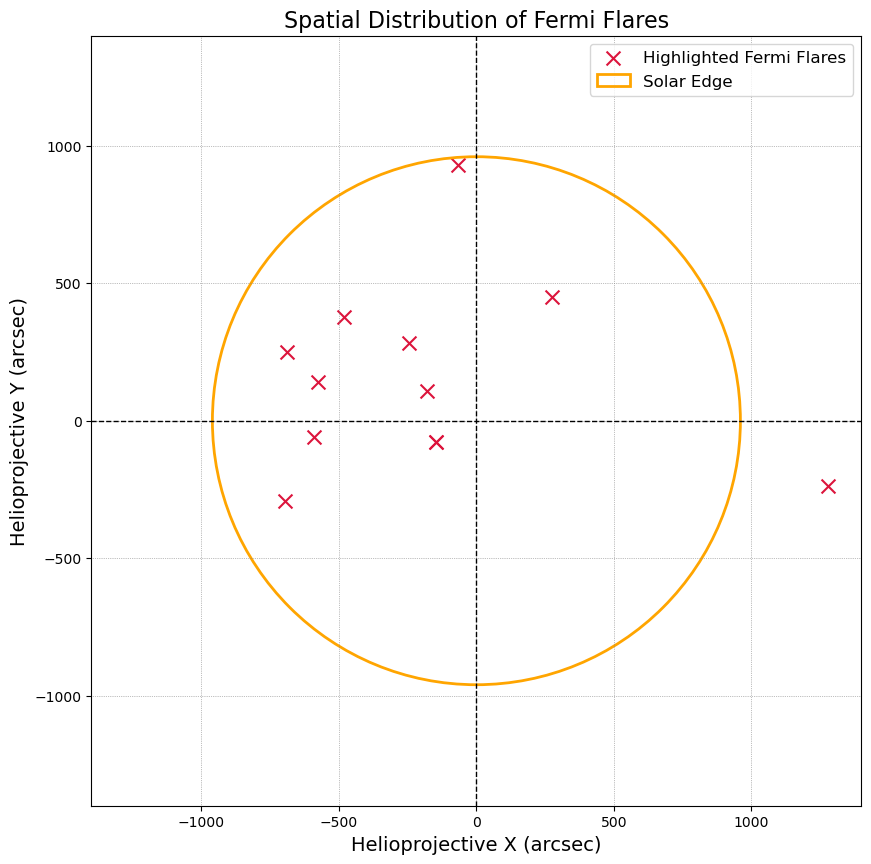

Note that 170910926 and 170910794 are stacked because they have similar location


In [ ]:

fig, ax = plt.subplots(figsize=(10, 10))

# Scatter plot the flares
ax.scatter(helio_x,
           helio_y,
           s=100, marker='x', color='crimson', 
           label='Highlighted Fermi Flares')

# Draw the boundary of the Sun
solar_circle = plt.Circle((0, 0), 960, edgecolor='orange',
                          facecolor='none', linewidth=2, label='Solar Edge')
ax.add_patch(solar_circle)

# 8. Axis and center lines
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)

# 9.Format the map
ax.grid(color='grey', linestyle=':', linewidth=0.5)
ax.set_aspect('equal', 'box') # ensures the Sun is a perfect circle
ax.set_xlim(-1400, 1400)
ax.set_ylim(-1400, 1400)
ax.set_xlabel('Helioprojective X (arcsec)', fontsize=14)
ax.set_ylabel('Helioprojective Y (arcsec)', fontsize=14)
ax.set_title('Spatial Distribution of Fermi Flares', fontsize=16)
ax.legend(loc='upper right', fontsize=12)

# Save the figure, uncomment
# plt.savefig('fermi_flares_distribution.png', dpi=150)
plt.show()

print ("Note that 170910926 and 170910794 are stacked because they have similar location") 

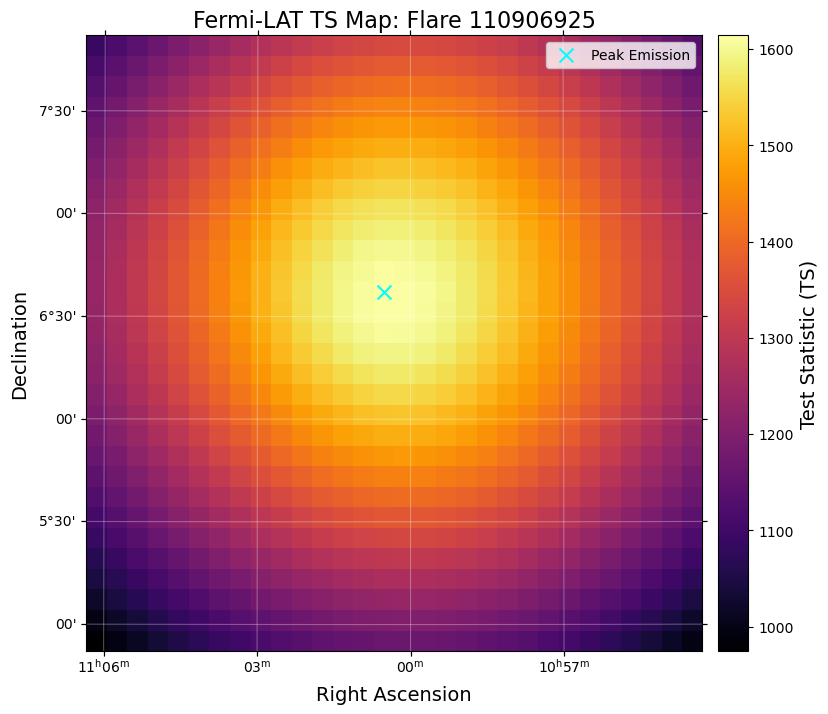

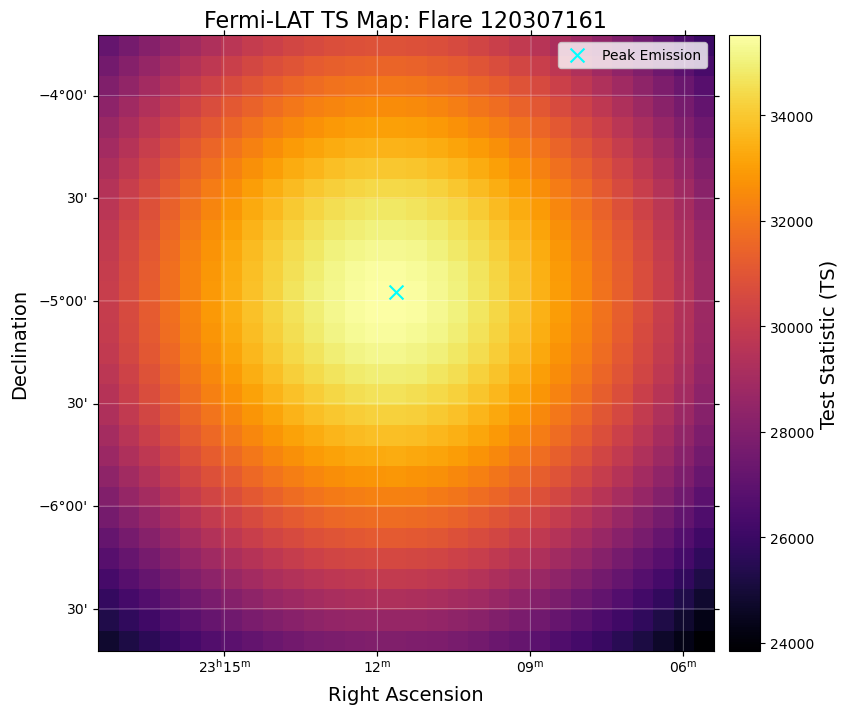

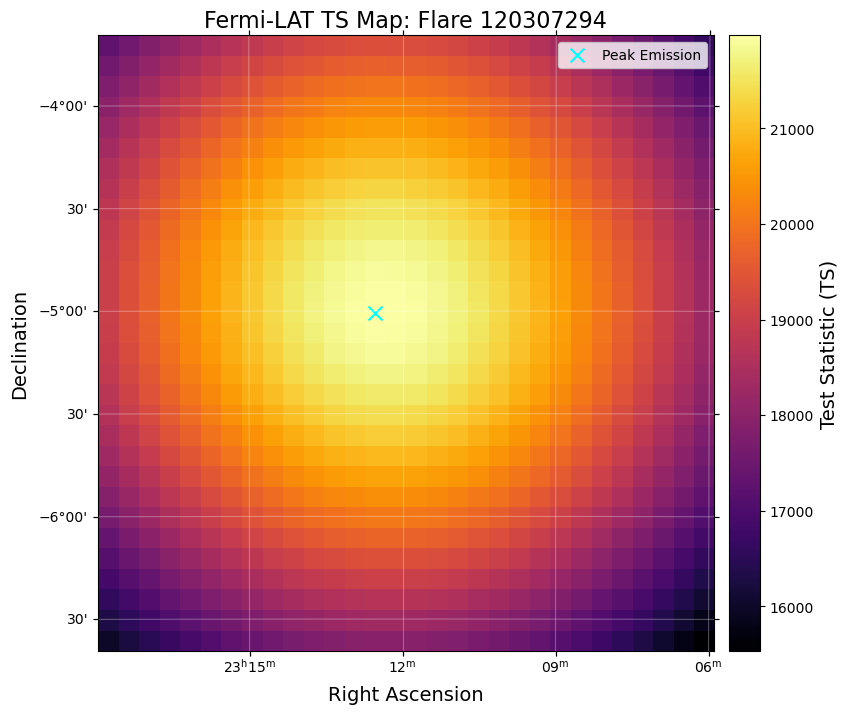

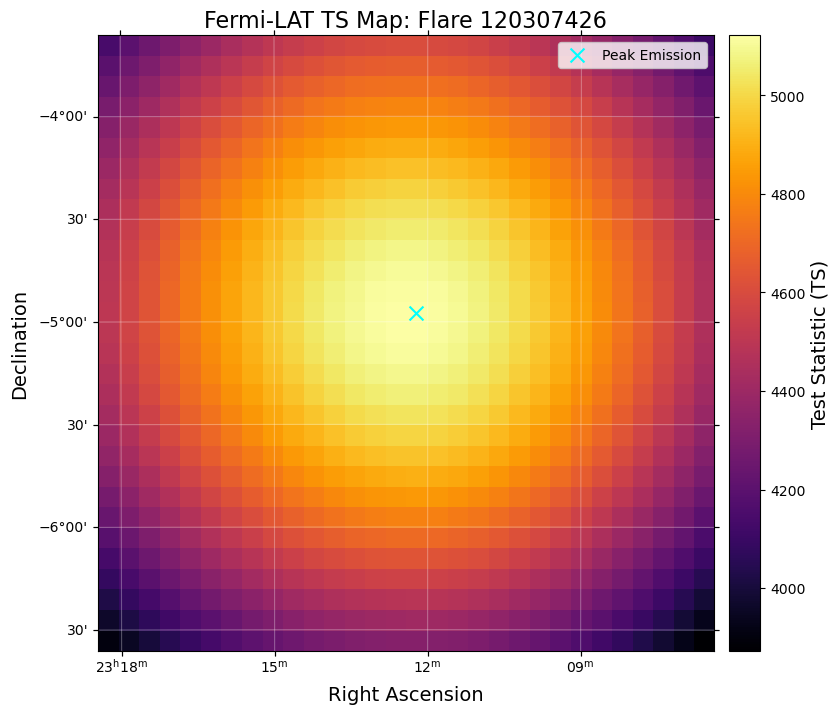

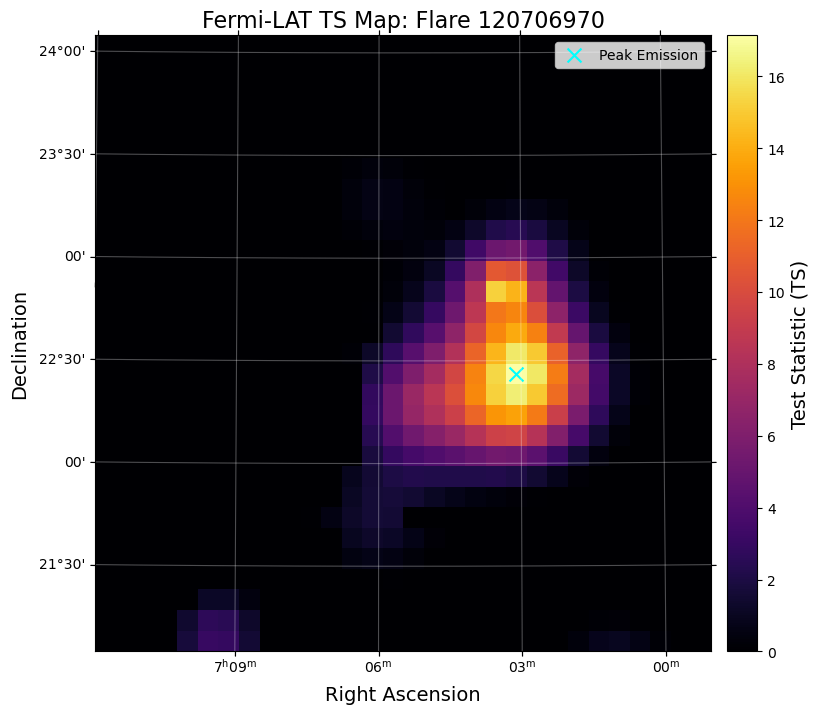

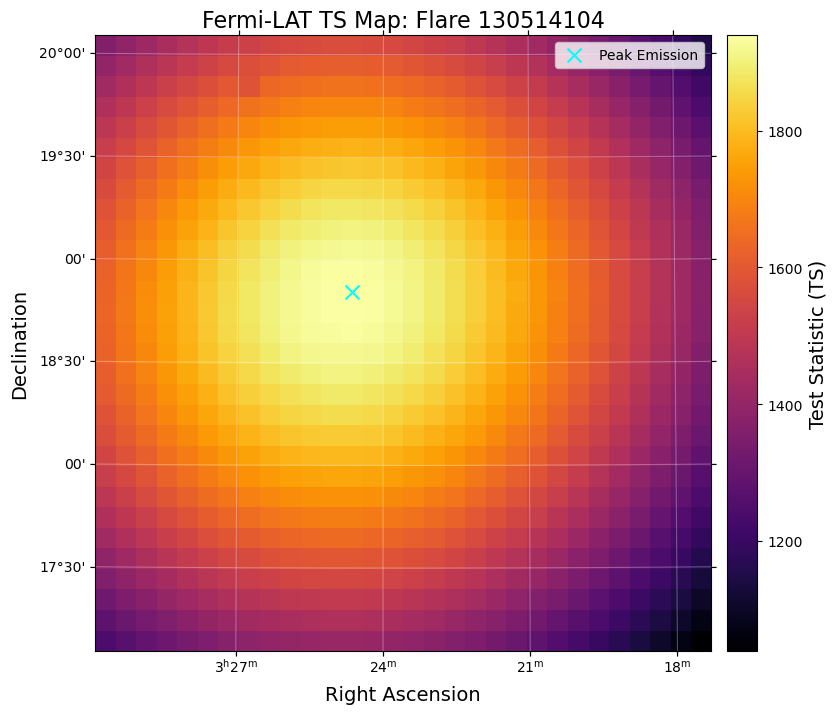

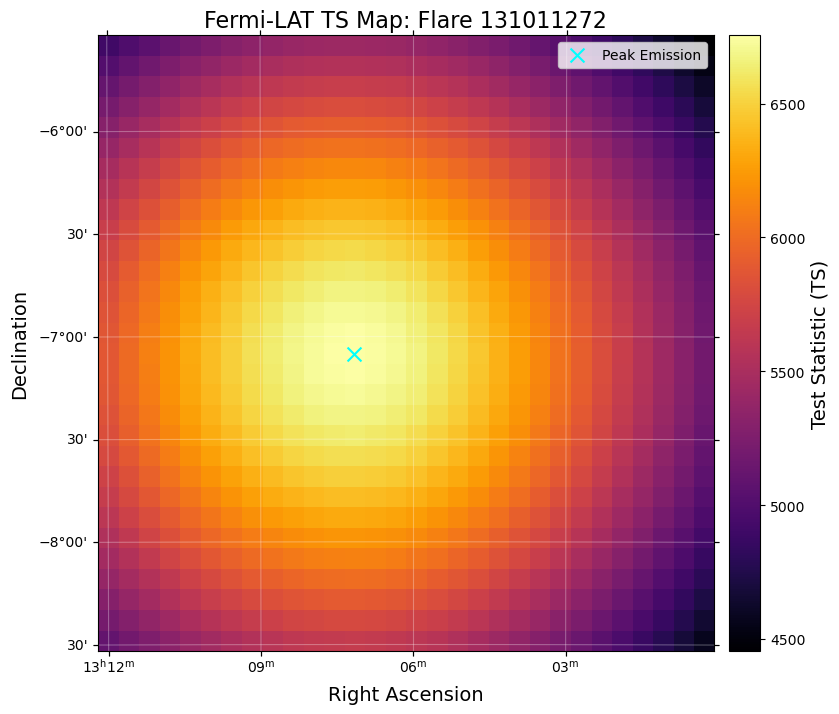

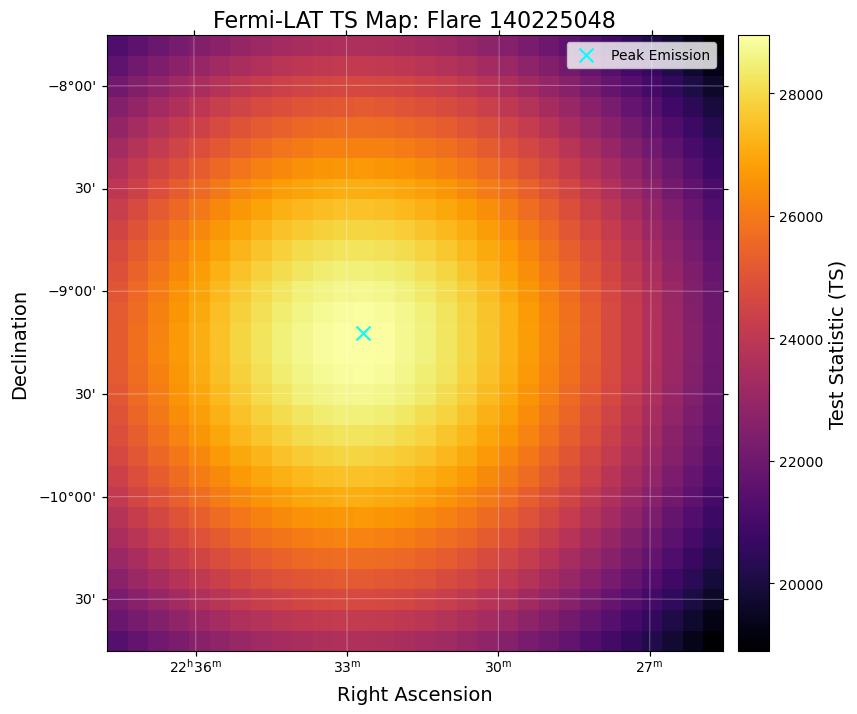

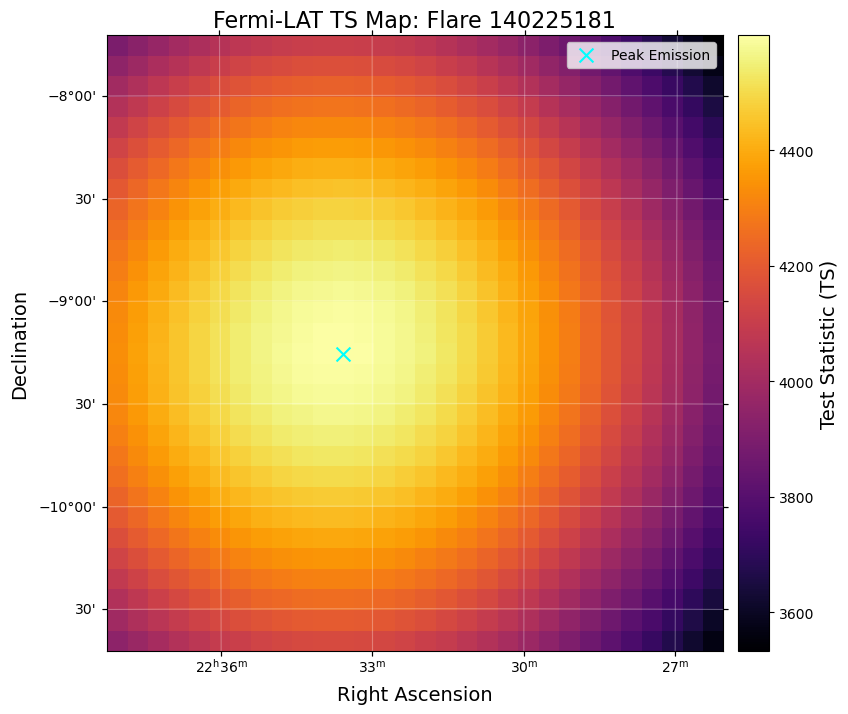

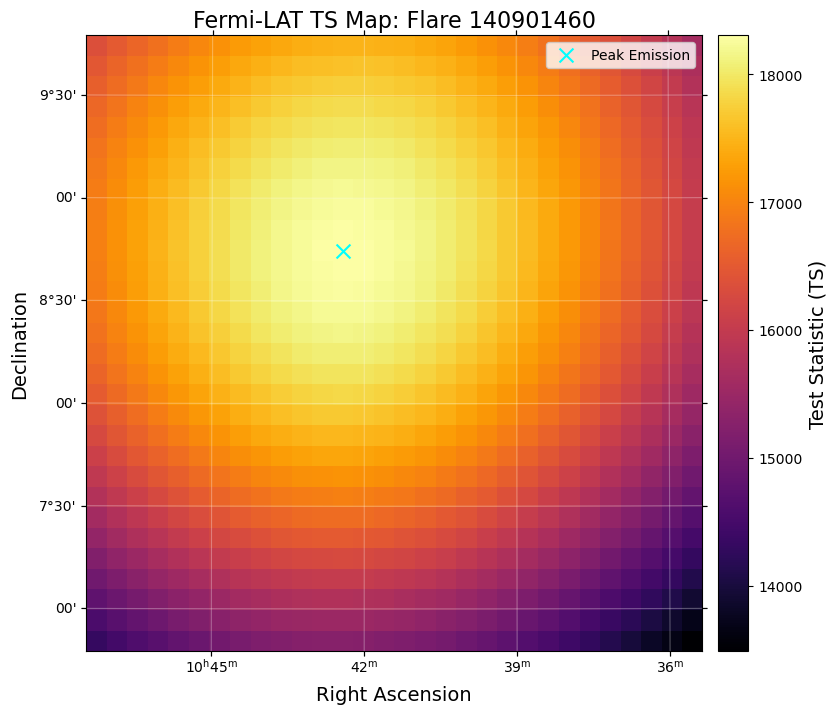

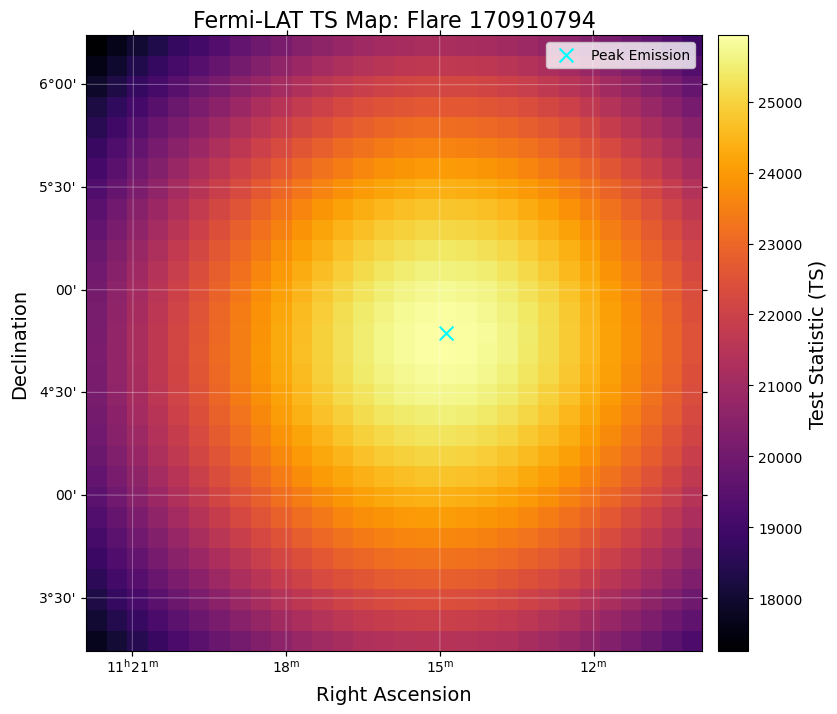

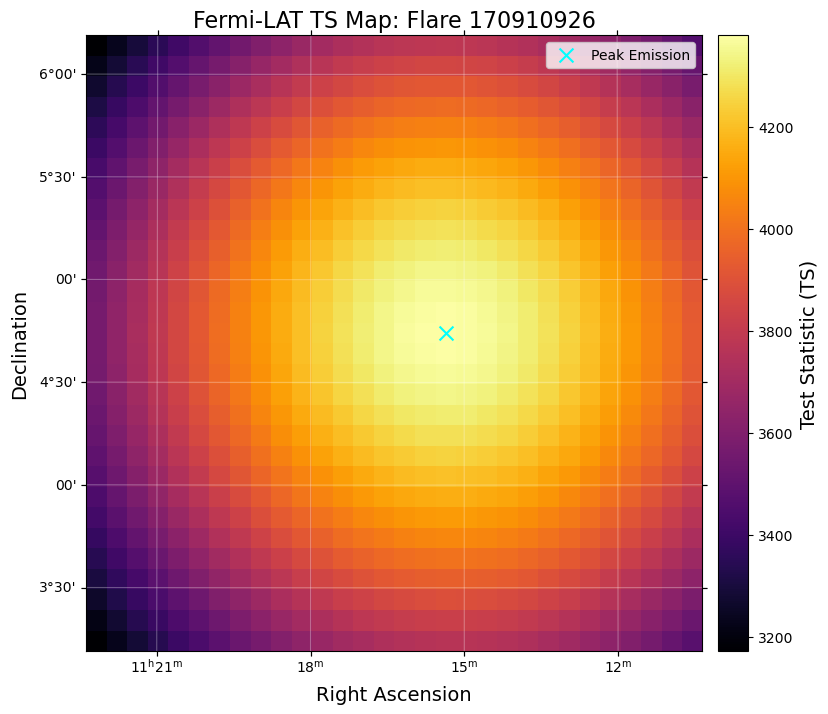

In [ ]:
#Test Statistics Map

for flare in flares:
    # Build the file path
    filepath = f"flare_{flare}/{flare}_tsmap.fits"
    
    
    # Open the TS Map file
    hdul = fits.open(filepath)
    ts_data = hdul[0].data
    header = hdul[0].header
    
    # Get the World Coordinate System 
    wcs = WCS(header)
    
    # Set up the figure and use WCS projection
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection=wcs)
    
    # Plot heat map
    im = ax.imshow(ts_data, origin='lower', cmap='inferno')
    
    # Colorbar
    cbar = plt.colorbar(im, pad=0.02)
    cbar.set_label('Test Statistic (TS)', fontsize=14)
    
    # Lbels and Title
    ax.grid(color='white', ls='solid', alpha=0.3)
    ax.set_xlabel('Right Ascension', fontsize=14)
    ax.set_ylabel('Declination', fontsize=14)
    ax.set_title(f'Fermi-LAT TS Map: Flare {flare}', fontsize=16)
    
    # Find the brightest pixel to put a marker on it
    max_y, max_x = np.unravel_index(np.argmax(ts_data, axis=None), ts_data.shape)
    ax.scatter(max_x, max_y, marker='x', color='cyan', s=100, label='Peak Emission')
    ax.legend()
    
    #  Save the figure as a PNG in the flare's folder, uncomment
    # output_png = f"flare_{flare}/{flare}_tsmap_plot.png"
    # plt.savefig(output_png, dpi=300, bbox_inches='tight')
    

